# Day 1

In [47]:
# Regression
# Predicting price when area is given
from sklearn.linear_model import LinearRegression
# Linear Regression model predicts continuous values

area = [[500], [700], [800], [2200]]
price = [5, 7, 8, 22]

In [48]:
model = LinearRegression()

In [49]:
model.fit(area, price) # finds relationship/pattern between area and price

LinearRegression()

In [50]:
prediction = model.predict([[1600]])
print("Predicted price: ", prediction)

Predicted price:  [16.]


In [51]:
# Classification
# Predict whether a person is pass or fail
from sklearn.linear_model import LogisticRegression
# Logistic Regression model predicts two values: 0 or 1

hours = [[1], [2], [3], [4], [5]]
result = [0, 0, 0, 1, 1] # 0=fail, 1=pass
model = LogisticRegression()

In [52]:
model.fit(hours, result)
prediction = model.predict([[8]])
print("Result: ", prediction)

Result:  [1]


In [53]:
# K-means clustering
from sklearn.cluster import KMeans
data = [[1, 2], [2, 3], [3, 4], [10, 10]]
model = KMeans(n_clusters=2)
model.fit(data)
print(model.labels_)
# think 0=group1, 1=group2

[0 0 0 1]


# Day 2

In [54]:
# Predict the no. of hrs the battery will last based on the battery capacity
from sklearn.linear_model import LinearRegression

battery = [[2000], [3000], [7000], [9000]]
backup = [8, 12, 16, 20]

model = LinearRegression()

model.fit(battery, backup)

prediction = model.predict([[8000]])
print("Predicted backup time: ", prediction)

Predicted backup time:  [18.19847328]


In [55]:
# loan approval prediction (salary attribute used to predict whether the loan should be given or not)
from sklearn.tree import DecisionTreeClassifier

salary = [[20], [30], [40], [60]]
loan_status = [0, 0, 1, 1]

model = DecisionTreeClassifier()

model.fit(salary, loan_status)

prediction = model.predict([[50]])
print("Loan status: ", prediction)


Loan status:  [1]


# Day 3

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [57]:
df = pd.read_csv("sales.csv")
print(df.head())

   customer_id signup_date country  age  gender loyalty_tier  \
0            1  08-04-2021      BR   48    Male       Bronze   
1            2  28-04-2023      IN   36  Female       Silver   
2            3  18-12-2022      UK   35  Female       Silver   
3            4  26-04-2022      US   45    Male       Silver   
4            5  20-04-2022      IN   53    Male       Silver   

  acquisition_channel  
0            Referral  
1             Organic  
2             Organic  
3         Paid Search  
4             Organic  


In [58]:
encoder = LabelEncoder()
df['loyalty_encoded'] = encoder.fit_transform(df['loyalty_tier'])
print(df[['loyalty_encoded']].head())
# Encoding: bronze=0, silver=3, etc

   loyalty_encoded
0                0
1                3
2                3
3                3
4                3


In [59]:
x = df[['age', 'loyalty_encoded']] # segmenting customers on the basis of these two features

In [60]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(x)

KMeans(n_clusters=3, random_state=42)

In [61]:
df['clusters'] = model.labels_
print('Clustered Customers')
print(model.cluster_centers_) # print centers of clusters

Clustered Customers
[[34.58076133  0.92589974]
 [46.76750959  0.91885965]
 [23.18103549  0.933002  ]]


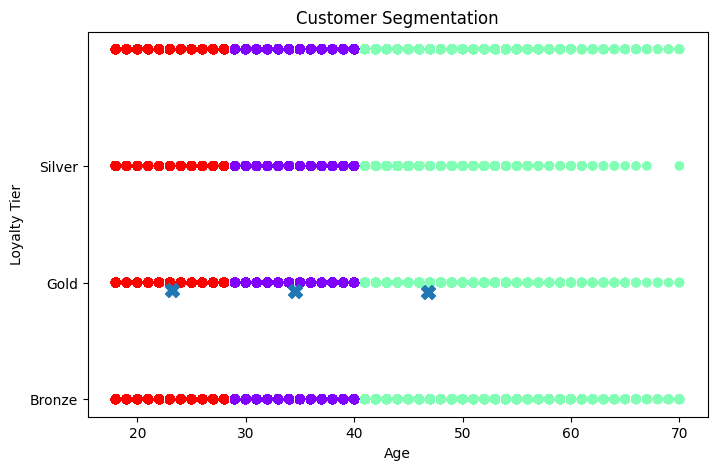

In [62]:
# represents age group segments i.e., clustering on the basis of age
plt.figure(figsize=(8,5))
plt.scatter(df['age'],
            df['loyalty_encoded'],
            c=df['clusters'],
            cmap='rainbow')


# representation of centroid for each group
plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            s=100,
            marker='X')


plt.xlabel('Age')
plt.ylabel('Loyalty Tier')
plt.title('Customer Segmentation')
plt.yticks([0,1,2],
          ['Bronze', 'Gold', 'Silver'])
plt.show()

# Day 4

In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [64]:
df = pd.read_csv("sales.csv")

In [65]:
encoder = LabelEncoder()
df['gender_encoded'] = encoder.fit_transform(df['gender'])
df['loyalty_encoded'] = encoder.fit_transform(df['loyalty_tier'])
df['country'] = encoder.fit_transform(df['country'])
df['channel_encoded'] = encoder.fit_transform(df['acquisition_channel'])

In [66]:
x = df[['age', 'gender_encoded',
        'country', 'channel_encoded']] #inputs
y = df['loyalty_encoded'] # output

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# splits the input (x) into two groups: train and test (x_train, x_test)
# same for output (y)
# test_size=0.2: testing phase should be 20%
# random_state=42: start the random process from seed 42. Every time you run the code, the train/test split will be identical.

In [67]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
predictions = model.predict(x_test)

accuracy = accuracy_score(
    y_test, predictions
)
print("Accuracy: ", accuracy)
# Accuracy:  0.6004 means model can predict 60% of the data points correctly

matrix = confusion_matrix(
    y_test, predictions
)
print(matrix)
# We got a 4x4 confusion matrix bcoz we have 4 classes in out output i.e., gold, silver, etc

# output:
#| Actual \ Predicted | Class 0 | Class 1 | Class 2 | Class 3 |
#| Class 0            |   12008 |       0 |       0 |       0 |
#| Class 1            |    2383 |       0 |       0 |       0 |
#| Class 2            |     636 |       0 |       0 |       0 |
#| Class 3            |    4973 |       0 |       0 |       0 |

# from this confusion matrix, we can infer that the model is only predicting class 0
# it might be due to imbalanced/underfitted dataset

Accuracy:  0.6004
[[12008     0     0     0]
 [ 2383     0     0     0]
 [  636     0     0     0]
 [ 4973     0     0     0]]


# Day 5

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [69]:
df = pd.read_csv("customer_retail.csv")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [70]:
df = df.dropna() # drop null cols

In [71]:
df = df[['Quantity', 'UnitPrice', 'Country']]

In [72]:
# converting text/categorial data into numbers
encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])

In [73]:
# we wanna predict country on the basis of unitprice and quantity i.e., classification problem

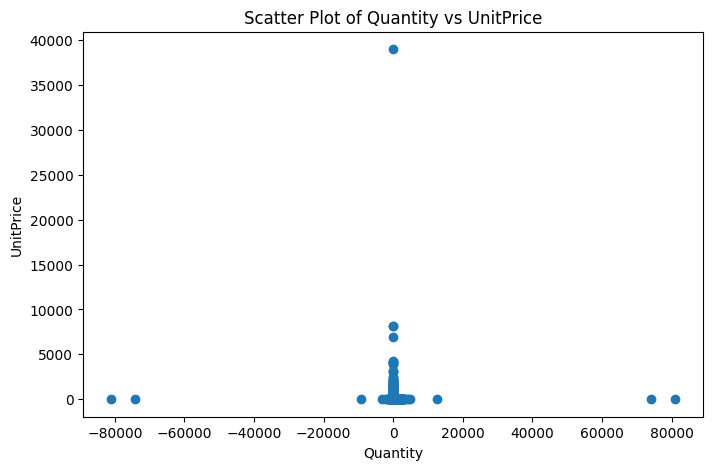

In [74]:
# to see overall ditribution of dataset
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()
# Interpretation: most of the data points are near low values and scattered over one region, whereas there are a bit of outliers too

In [75]:
x = df[['Quantity', 'UnitPrice']]
y = df['Country_encoded']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# splits the input (x) into two groups: train and test (x_train, x_test)
# same for output (y)
# test_size=0.2: testing phase should be 20%
# random_state=42: start the random process from seed 42. Every time you run the code, the train/test split will be identical.

In [76]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
y_pred = log_model.predict(x_test)

accuracy_log = accuracy_score(y_test, y_pred)
print('Accuracy: ', accuracy_log)
# Accuracy:  0.8797 means model can predict approx 87% of the data points correctly

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix')
print(cm)

Accuracy:  0.8897451023769142
Confusion Matrix
[[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    7     0     0 ...     0 72395     0]
 [    0     0     0 ...     0    43     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

accuracy_dt = accuracy_score(y_test, y_pred)
print('Accuracy: ', accuracy_dt)

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix')
print(cm)
# MOST ACCURATE!

Accuracy:  0.8902981589361649
Confusion Matrix
[[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   23     0     0 ...     1 72218     0]
 [    0     0     0 ...     0    43     0]]


In [78]:
# KNN
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
y_pred = knn_model.predict(x_test)

accuracy_knn = accuracy_score(y_test, y_pred)
print('Accuracy: ', accuracy_knn)

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix')
print(cm)
# LEAST ACCURATE

Accuracy:  0.8842268269301674
Confusion Matrix
[[   25     0     0 ...     0   181     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   41     2     0 ...     0 71636     0]
 [    0     0     0 ...     0    43     0]]


In [79]:
models = ['Logistic Regression',
          'Decision Tree',
          'KNN']
accuracies = [accuracy_log, accuracy_dt, accuracy_knn]

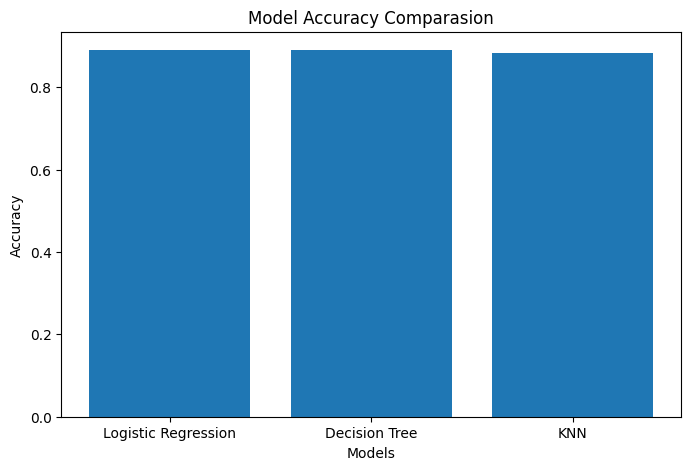

In [80]:
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparasion')
plt.show()